# Data Quality & Technical Risk Assessment for FX/CFD Trading Analytics

## Objective

This notebook adds a data governance and technical risk layer to the FX & CFD Trading Performance Analytics project.

Instead of only asking whether a trading strategy is profitable, this notebook evaluates whether the underlying data and analytics pipeline are reliable enough for trading performance review.

Key questions:

1. Are there missing values, duplicate records, or schema inconsistencies?
2. Are OHLC price records logically valid?
3. Are return, signal, cost, and PnL calculations internally consistent?
4. Are there abnormal market movements or cost spikes that may create technical or model risk?
5. Which assets have the highest data quality and operational risk exposure?

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Project paths
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "data_quality_risk_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Input files
raw_path = DATA_DIR / "raw_market_data.csv"
processed_path = DATA_DIR / "processed_market_data.csv"
signals_path = DATA_DIR / "trading_signals.csv"
performance_path = DATA_DIR / "trade_performance.csv"

raw = pd.read_csv(raw_path, parse_dates=["Date"])
processed = pd.read_csv(processed_path, parse_dates=["Date"])
signals = pd.read_csv(signals_path, parse_dates=["Date"])
perf = pd.read_csv(performance_path, parse_dates=["Date"])

print("Raw market data:", raw.shape)
print("Processed market data:", processed.shape)
print("Trading signals:", signals.shape)
print("Trade performance:", perf.shape)

Raw market data: (6362, 8)
Processed market data: (6117, 13)
Trading signals: (6117, 16)
Trade performance: (6117, 27)


## 1. Dataset Inventory

This section creates a simple inventory table for governance documentation.

In a real trading or financial analytics environment, a data inventory helps answer:

- where the data comes from;
- what each dataset is used for;
- how many rows and columns it contains;
- which date range it covers;
- whether the dataset can be reconciled with downstream outputs.

In [2]:
datasets = {
    "raw_market_data": raw,
    "processed_market_data": processed,
    "trading_signals": signals,
    "trade_performance": perf
}

inventory = []

for name, df in datasets.items():
    inventory.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "start_date": df["Date"].min(),
        "end_date": df["Date"].max(),
        "assets": df["asset"].nunique() if "asset" in df.columns else np.nan,
        "duplicate_rows": df.duplicated().sum()
    })

inventory_df = pd.DataFrame(inventory)
inventory_df.to_csv(OUTPUT_DIR / "dataset_inventory.csv", index=False)
inventory_df

,dataset,rows,columns,start_date,end_date,assets,duplicate_rows
0,raw_market_data,6362,8,2021-01-01,2025-12-30,5,0
1,processed_market_data,6117,13,2021-03-11,2025-12-30,5,0
2,trading_signals,6117,16,2021-03-11,2025-12-30,5,0
3,trade_performance,6117,27,2021-03-11,2025-12-30,5,0


## 2. Schema Validation

This section checks whether each dataset contains the required columns.

This is important because downstream calculations such as returns, moving averages, signals, transaction costs, and drawdown all depend on specific input fields.
If a required column is missing, the pipeline may still run incorrectly or silently produce misleading results.

In [3]:
required_columns = {
    "raw_market_data": ["Date", "Open", "High", "Low", "Close", "Volume", "asset", "ticker"],
    "processed_market_data": ["Date", "Open", "High", "Low", "Close", "Volume", "asset", "ticker", 
                              "daily_return", "log_return", "volatility_20d", "ma_20", "ma_50"],
    "trading_signals": ["Date", "asset", "Close", "ma_20", "ma_50", "signal", "position", 
                        "strategy_return_before_cost"],
    "trade_performance": ["Date", "asset", "daily_return", "position", "turnover", 
                          "transaction_cost", "slippage_cost", "total_cost",
                          "strategy_return_before_cost", "strategy_return_after_cost",
                          "equity_curve_after_cost", "drawdown_after_cost"]
}

schema_results = []

for name, expected_cols in required_columns.items():
    df = datasets[name]
    actual_cols = set(df.columns)
    missing_cols = [col for col in expected_cols if col not in actual_cols]
    extra_cols = [col for col in df.columns if col not in expected_cols]

    schema_results.append({
        "dataset": name,
        "missing_required_columns": ", ".join(missing_cols) if missing_cols else "None",
        "extra_columns_count": len(extra_cols),
        "schema_status": "PASS" if not missing_cols else "FAIL"
    })

schema_df = pd.DataFrame(schema_results)
schema_df.to_csv(OUTPUT_DIR / "schema_validation.csv", index=False)
schema_df

,dataset,missing_required_columns,extra_columns_count,schema_status
0,raw_market_data,None,0,PASS
1,processed_market_data,None,0,PASS
2,trading_signals,None,8,PASS
3,trade_performance,None,15,PASS


## 3. Missing Value and Duplicate Check

Missing values may be acceptable in early rolling-window periods, for example moving average or volatility features.
However, missing values in key trading fields such as close price, return, position, or cost are high risk because they directly affect PnL and performance metrics.

In [4]:
critical_columns = ["Date", "asset", "Close", "daily_return", "position", 
                    "strategy_return_after_cost", "total_cost", "drawdown_after_cost"]

missing_summary = []

for name, df in datasets.items():
    available_critical_cols = [col for col in critical_columns if col in df.columns]

    for col in available_critical_cols:
        missing_count = df[col].isna().sum()
        missing_summary.append({
            "dataset": name,
            "column": col,
            "missing_count": missing_count,
            "missing_rate": missing_count / len(df)
        })

missing_df = pd.DataFrame(missing_summary)
missing_df["risk_level"] = np.where(
    missing_df["missing_rate"] == 0, "Low",
    np.where(missing_df["missing_rate"] <= 0.01, "Medium", "High")
)

duplicate_key_summary = []

for name, df in datasets.items():
    if {"Date", "asset"}.issubset(df.columns):
        dup_count = df.duplicated(subset=["Date", "asset"]).sum()
        duplicate_key_summary.append({
            "dataset": name,
            "duplicate_date_asset_records": dup_count,
            "risk_level": "Low" if dup_count == 0 else "High"
        })

duplicate_df = pd.DataFrame(duplicate_key_summary)

missing_df.to_csv(OUTPUT_DIR / "missing_value_summary.csv", index=False)
duplicate_df.to_csv(OUTPUT_DIR / "duplicate_key_summary.csv", index=False)

display(missing_df.sort_values(["risk_level", "missing_rate"], ascending=[True, False]))
display(duplicate_df)

,dataset,column,missing_count,missing_rate,risk_level
0,raw_market_data,Date,0,0.0,Low
1,raw_market_data,asset,0,0.0,Low
2,raw_market_data,Close,0,0.0,Low
3,processed_market_data,Date,0,0.0,Low
4,processed_market_data,asset,0,0.0,Low
5,processed_market_data,Close,0,0.0,Low
6,processed_market_data,daily_return,0,0.0,Low
7,trading_signals,Date,0,0.0,Low
8,trading_signals,asset,0,0.0,Low
9,trading_signals,Close,0,0.0,Low


,dataset,duplicate_date_asset_records,risk_level
0,raw_market_data,0,Low
1,processed_market_data,0,Low
2,trading_signals,0,Low
3,trade_performance,0,Low


## 4. OHLC Price Integrity Checks

For market data, the following rules should generally hold:

- High should be greater than or equal to Open, Low, and Close.
- Low should be less than or equal to Open, High, and Close.
- Open, High, Low, and Close should be positive.
- A zero or negative price is invalid for normal FX/CFD market data.

These checks help identify vendor errors, corrupted files, or transformation mistakes.

In [5]:
ohlc = raw.copy()

price_cols = ["Open", "High", "Low", "Close"]

ohlc["invalid_high"] = (
    (ohlc["High"] < ohlc["Open"]) |
    (ohlc["High"] < ohlc["Low"]) |
    (ohlc["High"] < ohlc["Close"])
)

ohlc["invalid_low"] = (
    (ohlc["Low"] > ohlc["Open"]) |
    (ohlc["Low"] > ohlc["High"]) |
    (ohlc["Low"] > ohlc["Close"])
)

ohlc["non_positive_price"] = (ohlc[price_cols] <= 0).any(axis=1)

ohlc["ohlc_issue_flag"] = (
    ohlc["invalid_high"] |
    ohlc["invalid_low"] |
    ohlc["non_positive_price"]
)

ohlc_issue_summary = (
    ohlc.groupby("asset")
    .agg(
        total_records=("Date", "count"),
        invalid_high_records=("invalid_high", "sum"),
        invalid_low_records=("invalid_low", "sum"),
        non_positive_price_records=("non_positive_price", "sum"),
        total_ohlc_issues=("ohlc_issue_flag", "sum")
    )
    .reset_index()
)

ohlc_issue_summary["ohlc_issue_rate"] = (
    ohlc_issue_summary["total_ohlc_issues"] / ohlc_issue_summary["total_records"]
)

ohlc_issue_summary["risk_level"] = np.select(
    [
        ohlc_issue_summary["ohlc_issue_rate"] == 0,
        ohlc_issue_summary["ohlc_issue_rate"] <= 0.005
    ],
    ["Low", "Medium"],
    default="High"
)

ohlc_issue_summary.to_csv(OUTPUT_DIR / "ohlc_integrity_summary.csv", index=False)
ohlc_issue_summary

,asset,total_records,invalid_high_records,invalid_low_records,non_positive_price_records,total_ohlc_issues,ohlc_issue_rate,risk_level
0,AUDUSD,1299,25,21,0,46,0.035412,High
1,EURUSD,1299,14,16,0,30,0.023095,High
2,GOLD,1256,0,0,0,0,0.000000,Low
3,NASDAQ100,1254,0,0,0,0,0.000000,Low
4,SP500,1254,0,0,0,0,0.000000,Low


## 5. Date Continuity and Coverage Check

Trading data does not need to contain every calendar day because weekends and market holidays exist.
However, large unexplained gaps can still be a data coverage risk.

This section flags unusually long gaps within each asset's time series.

In [6]:
date_gap_records = []

for asset, group in raw.sort_values(["asset", "Date"]).groupby("asset"):
    g = group[["Date", "asset"]].drop_duplicates().sort_values("Date").copy()
    g["previous_date"] = g["Date"].shift(1)
    g["gap_days"] = (g["Date"] - g["previous_date"]).dt.days

    suspicious_gaps = g[g["gap_days"] > 7].copy()

    for _, row in suspicious_gaps.iterrows():
        date_gap_records.append({
            "asset": asset,
            "previous_date": row["previous_date"],
            "current_date": row["Date"],
            "gap_days": row["gap_days"]
        })

date_gap_df = pd.DataFrame(date_gap_records)

if len(date_gap_df) == 0:
    date_gap_summary = pd.DataFrame({
        "status": ["PASS"],
        "message": ["No suspicious gaps greater than 7 days were detected."]
    })
else:
    date_gap_summary = (
        date_gap_df.groupby("asset")
        .agg(suspicious_gap_count=("gap_days", "count"),
             max_gap_days=("gap_days", "max"))
        .reset_index()
    )

date_gap_df.to_csv(OUTPUT_DIR / "date_gap_details.csv", index=False)
date_gap_summary.to_csv(OUTPUT_DIR / "date_gap_summary.csv", index=False)

display(date_gap_summary)
display(date_gap_df.head(20))

,status,message
0,PASS,No suspicious gaps greater than 7 days were de...


""


## 6. Return Calculation Reconciliation

This check recalculates daily returns from Close prices and compares them with the stored `daily_return`.

This is a reconciliation control. It verifies whether a key analytical field can be independently reproduced from source price data.

In [7]:
return_check = processed.sort_values(["asset", "Date"]).copy()

return_check["recalculated_daily_return"] = (
    return_check.groupby("asset")["Close"].pct_change()
)

return_check["return_diff"] = (
    return_check["daily_return"] - return_check["recalculated_daily_return"]
).abs()

# Ignore the first record per asset because pct_change is naturally missing there.
return_check_valid = return_check.dropna(subset=["recalculated_daily_return"]).copy()

tolerance = 1e-8
return_recon_summary = (
    return_check_valid.groupby("asset")
    .agg(
        checked_records=("Date", "count"),
        max_return_diff=("return_diff", "max"),
        failed_return_reconciliation=("return_diff", lambda x: (x > tolerance).sum())
    )
    .reset_index()
)

return_recon_summary["risk_level"] = np.where(
    return_recon_summary["failed_return_reconciliation"] == 0, "Low", "High"
)

return_recon_summary.to_csv(OUTPUT_DIR / "return_reconciliation_summary.csv", index=False)
return_recon_summary

,asset,checked_records,max_return_diff,failed_return_reconciliation,risk_level
0,AUDUSD,1249,9.996344e-17,0,Low
1,EURUSD,1249,5.358669e-16,0,Low
2,GOLD,1206,9.887924e-17,0,Low
3,NASDAQ100,1204,9.974660e-17,0,Low
4,SP500,1204,9.985502e-17,0,Low


## 7. Signal Logic Reconciliation

The current strategy logic is:

- if MA20 > MA50, signal = 1;
- otherwise signal = 0.

This section checks whether the stored signal follows the documented strategy rule.

In [8]:
signal_check = signals.copy()

signal_check["expected_signal"] = np.where(signal_check["ma_20"] > signal_check["ma_50"], 1, 0)
signal_check["signal_mismatch"] = signal_check["signal"] != signal_check["expected_signal"]

signal_summary = (
    signal_check.groupby("asset")
    .agg(
        checked_records=("Date", "count"),
        signal_mismatch_count=("signal_mismatch", "sum")
    )
    .reset_index()
)

signal_summary["signal_mismatch_rate"] = (
    signal_summary["signal_mismatch_count"] / signal_summary["checked_records"]
)

signal_summary["risk_level"] = np.where(
    signal_summary["signal_mismatch_count"] == 0, "Low", "High"
)

signal_summary.to_csv(OUTPUT_DIR / "signal_logic_reconciliation.csv", index=False)
signal_summary

,asset,checked_records,signal_mismatch_count,signal_mismatch_rate,risk_level
0,AUDUSD,1250,0,0.0,Low
1,EURUSD,1250,0,0.0,Low
2,GOLD,1207,0,0.0,Low
3,NASDAQ100,1205,0,0.0,Low
4,SP500,1205,0,0.0,Low


## 8. Cost and PnL Reconciliation

This section checks two important accounting-style controls:

1. `total_cost = transaction_cost + slippage_cost`
2. `strategy_return_after_cost = strategy_return_before_cost - total_cost`

These checks are important because trading performance can be overstated if costs are missing or incorrectly applied.

In [15]:
cost_check = perf.copy()

cost_check["expected_total_cost"] = (
    cost_check["transaction_cost"] + cost_check["slippage_cost"]
)

cost_check["total_cost_diff"] = (
    cost_check["total_cost"] - cost_check["expected_total_cost"]
).abs()

cost_check["expected_after_cost_return"] = (
    cost_check["strategy_return_before_cost"] - cost_check["total_cost"]
)

cost_check["after_cost_return_diff"] = (
    cost_check["strategy_return_after_cost"] - cost_check["expected_after_cost_return"]
).abs()

cost_tolerance = 1e-10

cost_recon_summary = (
    cost_check.groupby("asset")
    .agg(
        checked_records=("Date", "count"),
        total_cost_recon_failures=("total_cost_diff", lambda x: (x > cost_tolerance).sum()),
        after_cost_return_recon_failures=("after_cost_return_diff", lambda x: (x > cost_tolerance).sum()),
        max_total_cost_diff=("total_cost_diff", "max"),
        max_after_cost_return_diff=("after_cost_return_diff", "max")
    )
    .reset_index()
)

cost_recon_summary["risk_level"] = np.where(
    (cost_recon_summary["total_cost_recon_failures"] == 0) &
    (cost_recon_summary["after_cost_return_recon_failures"] == 0),
    "Low",
    "High"
)

cost_recon_summary.to_csv(OUTPUT_DIR / "cost_pnl_reconciliation_summary.csv", index=False)
cost_recon_summary

,asset,checked_records,total_cost_recon_failures,after_cost_return_recon_failures,max_total_cost_diff,max_after_cost_return_diff,risk_level
0,AUDUSD,1250,0,0,1.084202e-19,1.006140e-16,Low
1,EURUSD,1250,0,0,1.084202e-19,1.006140e-16,Low
2,GOLD,1207,0,0,2.168404e-19,1.006140e-16,Low
3,NASDAQ100,1205,0,0,2.168404e-19,1.006140e-16,Low
4,SP500,1205,0,0,2.168404e-19,1.006140e-16,Low


## 9. Outlier and Market Data Risk Detection

This section flags extreme daily returns and high-cost trading days.

These are not necessarily errors. They may reflect real market stress.
However, they should be reviewed because they can strongly affect backtesting results, drawdowns, and risk-adjusted performance.

In [23]:
risk = perf.copy()

# Z-score of daily return by asset
risk["return_mean"] = risk.groupby("asset")["daily_return"].transform("mean")
risk["return_std"] = risk.groupby("asset")["daily_return"].transform("std")
risk["return_zscore"] = (
    (risk["daily_return"] - risk["return_mean"]) / risk["return_std"]
)

# Extreme return event: absolute z-score greater than 3
risk["extreme_return_flag"] = risk["return_zscore"].abs() > 3

# High cost event:
# Only compare positive-cost days within each asset.
# A day is high-cost if its total_cost is above the 95th percentile of positive-cost days.
def flag_high_cost(group):
    positive_costs = group.loc[group["total_cost"] > 0, "total_cost"]
    if positive_costs.empty:
        group["high_cost_flag"] = False
    else:
        threshold = positive_costs.quantile(0.95)
        group["high_cost_flag"] = group["total_cost"] > threshold
    return group

risk = risk.groupby("asset", group_keys=False).apply(flag_high_cost)

# Severe drawdown state:
# Flag days where after-cost drawdown is below -10%
risk["severe_drawdown_flag"] = risk["drawdown_after_cost"] < -0.10

technical_risk_summary = (
    risk.groupby("asset")
    .agg(
        records=("Date", "count"),
        extreme_return_days=("extreme_return_flag", "sum"),
        high_cost_days=("high_cost_flag", "sum"),
        severe_drawdown_days=("severe_drawdown_flag", "sum"),
        max_abs_return_zscore=("return_zscore", lambda x: x.abs().max()),
        max_total_cost=("total_cost", "max"),
        worst_drawdown=("drawdown_after_cost", "min"),
    )
    .reset_index()
)

technical_risk_summary

/var/folders/56/5hhy_nc96sd14853bqkqxlg00000gn/T/ipykernel_17734/2738170616.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk = risk.groupby("asset", group_keys=False).apply(flag_high_cost)


,asset,records,extreme_return_days,high_cost_days,severe_drawdown_days,max_abs_return_zscore,max_total_cost,worst_drawdown
0,AUDUSD,1250,12,2,1002,8.191773,0.001380,-0.331601
1,EURUSD,1250,13,2,0,5.870823,0.000940,-0.086747
2,GOLD,1207,12,2,180,5.818088,0.001628,-0.145503
3,NASDAQ100,1205,10,2,399,8.325228,0.002753,-0.280557
4,SP500,1205,13,2,848,8.844750,0.002086,-0.311713


## 10. Data Quality Risk Scorecard

This scorecard converts individual checks into a simple risk scoring table.

Scoring logic:

- Missing critical values: higher missing rate means higher risk.
- Duplicate Date-Asset keys: duplicates are high risk.
- OHLC violations: invalid market prices are high risk.
- Return reconciliation failures: high risk because returns drive strategy PnL.
- Signal mismatches: high risk because they break strategy logic.
- Cost/PnL reconciliation failures: high risk because performance may be overstated.
- Technical risk events: not always data errors, but require review.

In [24]:
# ============================================================
# Risk Scorecard
# ============================================================

assets = sorted(perf["asset"].unique())
scorecard = pd.DataFrame({"asset": assets})

# ---------- 1. OHLC summary compatibility ----------
if "ohlc_issue_summary" in globals():
    ohlc_for_score = ohlc_issue_summary.copy()
elif "ohlc_summary" in globals():
    ohlc_for_score = ohlc_summary.copy()
elif "ohlc_integrity_summary" in globals():
    ohlc_for_score = ohlc_integrity_summary.copy()
else:
    ohlc_for_score = pd.DataFrame({
        "asset": assets,
        "total_ohlc_issues": 0
    })

# Ensure total_ohlc_issues exists
if "total_ohlc_issues" not in ohlc_for_score.columns:
    issue_cols = [
        col for col in ohlc_for_score.columns
        if "issue" in col.lower() or "invalid" in col.lower() or "failure" in col.lower()
    ]
    if issue_cols:
        ohlc_for_score["total_ohlc_issues"] = ohlc_for_score[issue_cols].sum(axis=1)
    else:
        ohlc_for_score["total_ohlc_issues"] = 0

scorecard = scorecard.merge(
    ohlc_for_score[["asset", "total_ohlc_issues"]],
    on="asset",
    how="left"
)

# ---------- 2. Return reconciliation ----------
if "return_summary" in globals():
    return_for_score = return_summary.copy()
elif "return_reconciliation_summary" in globals():
    return_for_score = return_reconciliation_summary.copy()
else:
    return_for_score = pd.DataFrame({
        "asset": assets,
        "failed_return_reconciliation": 0
    })

if "failed_return_reconciliation" not in return_for_score.columns:
    possible_cols = [
        col for col in return_for_score.columns
        if "fail" in col.lower() or "mismatch" in col.lower()
    ]
    if possible_cols:
        return_for_score["failed_return_reconciliation"] = return_for_score[possible_cols].sum(axis=1)
    else:
        return_for_score["failed_return_reconciliation"] = 0

scorecard = scorecard.merge(
    return_for_score[["asset", "failed_return_reconciliation"]],
    on="asset",
    how="left"
)

# ---------- 3. Signal logic reconciliation ----------
if "signal_summary" in globals():
    signal_for_score = signal_summary.copy()
elif "signal_logic_reconciliation" in globals():
    signal_for_score = signal_logic_reconciliation.copy()
else:
    signal_for_score = pd.DataFrame({
        "asset": assets,
        "signal_mismatch_count": 0
    })

if "signal_mismatch_count" not in signal_for_score.columns:
    possible_cols = [
        col for col in signal_for_score.columns
        if "mismatch" in col.lower() or "fail" in col.lower()
    ]
    if possible_cols:
        signal_for_score["signal_mismatch_count"] = signal_for_score[possible_cols].sum(axis=1)
    else:
        signal_for_score["signal_mismatch_count"] = 0

scorecard = scorecard.merge(
    signal_for_score[["asset", "signal_mismatch_count"]],
    on="asset",
    how="left"
)

# ---------- 4. Cost and PnL reconciliation ----------
if "cost_summary" in globals():
    cost_for_score = cost_summary.copy()
elif "cost_pnl_reconciliation_summary" in globals():
    cost_for_score = cost_pnl_reconciliation_summary.copy()
else:
    cost_for_score = pd.DataFrame({
        "asset": assets,
        "total_cost_recon_failures": 0,
        "after_cost_return_recon_failures": 0
    })

for col in ["total_cost_recon_failures", "after_cost_return_recon_failures"]:
    if col not in cost_for_score.columns:
        cost_for_score[col] = 0

scorecard = scorecard.merge(
    cost_for_score[
        [
            "asset",
            "total_cost_recon_failures",
            "after_cost_return_recon_failures"
        ]
    ],
    on="asset",
    how="left"
)

# ---------- 5. Technical risk events ----------
if "technical_risk_summary" in globals():
    technical_for_score = technical_risk_summary.copy()
else:
    technical_for_score = pd.DataFrame({
        "asset": assets,
        "extreme_return_days": 0,
        "high_cost_days": 0,
        "severe_drawdown_days": 0,
        "worst_drawdown": 0
    })

for col in ["extreme_return_days", "high_cost_days", "severe_drawdown_days", "worst_drawdown"]:
    if col not in technical_for_score.columns:
        technical_for_score[col] = 0

scorecard = scorecard.merge(
    technical_for_score[
        [
            "asset",
            "extreme_return_days",
            "high_cost_days",
            "severe_drawdown_days",
            "worst_drawdown"
        ]
    ],
    on="asset",
    how="left"
)

# ---------- 6. Fill missing values ----------
scorecard = scorecard.fillna(0)

# ---------- 7. Calculate data quality risk score ----------
scorecard["data_quality_risk_score"] = (
    scorecard["total_ohlc_issues"] * 5
    + scorecard["failed_return_reconciliation"] * 10
    + scorecard["signal_mismatch_count"] * 8
    + scorecard["total_cost_recon_failures"] * 8
    + scorecard["after_cost_return_recon_failures"] * 8
    + scorecard["extreme_return_days"] * 2
    + scorecard["high_cost_days"] * 2
)

# ---------- 8. Performance risk level based on worst drawdown ----------
def classify_performance_risk(drawdown):
    if drawdown <= -0.30:
        return "High"
    elif drawdown <= -0.15:
        return "Medium"
    elif drawdown <= -0.05:
        return "Low"
    else:
        return "Very Low"

scorecard["performance_risk_level"] = scorecard["worst_drawdown"].apply(classify_performance_risk)

# ---------- 9. Overall data quality risk level ----------
def classify_data_quality_risk(score):
    if score >= 300:
        return "High"
    elif score >= 100:
        return "Medium"
    elif score > 0:
        return "Low"
    else:
        return "Very Low"

scorecard["overall_data_quality_risk_level"] = (
    scorecard["data_quality_risk_score"].apply(classify_data_quality_risk)
)

scorecard = scorecard.sort_values("data_quality_risk_score", ascending=False)


scorecard
scorecard.to_csv(OUTPUT_DIR / "data_quality_risk_scorecard.csv", index=False)

,asset,total_ohlc_issues,failed_return_reconciliation,signal_mismatch_count,total_cost_recon_failures,after_cost_return_recon_failures,extreme_return_days,high_cost_days,severe_drawdown_days,worst_drawdown,data_quality_risk_score,performance_risk_level,overall_data_quality_risk_level
0,AUDUSD,46,0,0,0,0,12,2,1002,-0.331601,258,High,Medium
1,EURUSD,30,0,0,0,0,13,2,0,-0.086747,180,Low,Medium
4,SP500,0,0,0,0,0,13,2,848,-0.311713,30,High,Low
2,GOLD,0,0,0,0,0,12,2,180,-0.145503,28,Low,Low
3,NASDAQ100,0,0,0,0,0,10,2,399,-0.280557,24,Medium,Low


## 11. Visualisation: Data Quality Risk Score by Asset

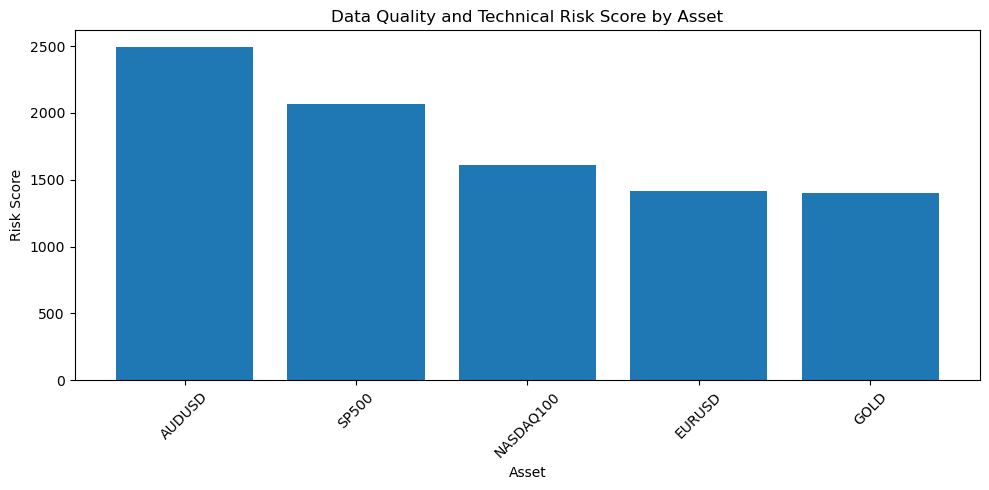

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(scorecard["asset"], scorecard["data_quality_risk_score"])
plt.title("Data Quality and Technical Risk Score by Asset")
plt.xlabel("Asset")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_quality_risk_score_by_asset.png", dpi=300)
plt.show()

## 12. Governance Findings and Recommendations

This section translates technical checks into business-facing findings.

In a resume, report, or interview, the key message is:

> I did not only build a backtest. I also built data quality controls and technical risk checks to make sure the trading analytics workflow is reliable, auditable, and explainable.

In [21]:
total_checks = {
    "schema_failures": (schema_df["schema_status"] == "FAIL").sum(),
    "duplicate_key_issues": duplicate_df["duplicate_date_asset_records"].sum(),
    "ohlc_issues": ohlc_issue_summary["total_ohlc_issues"].sum(),
    "return_reconciliation_failures": return_recon_summary["failed_return_reconciliation"].sum(),
    "signal_mismatches": signal_summary["signal_mismatch_count"].sum(),
    "cost_reconciliation_failures": (
        cost_recon_summary["total_cost_recon_failures"].sum() +
        cost_recon_summary["after_cost_return_recon_failures"].sum()
    ),
    "technical_risk_events": (
    technical_risk_summary["extreme_return_days"].sum()
    + technical_risk_summary["high_cost_days"].sum()
)
}

governance_summary = pd.DataFrame([
    {
        "control_area": "Schema validation",
        "finding": f"{total_checks['schema_failures']} dataset(s) failed required-column checks.",
        "recommendation": "Maintain a data dictionary and validate required fields before running analytics."
    },
    {
        "control_area": "Uniqueness control",
        "finding": f"{total_checks['duplicate_key_issues']} duplicate Date-Asset records detected.",
        "recommendation": "Enforce Date-Asset as a unique key for market and performance tables."
    },
    {
        "control_area": "Market data integrity",
        "finding": f"{total_checks['ohlc_issues']} OHLC price integrity issues detected.",
        "recommendation": "Flag invalid prices before calculating returns or trading signals."
    },
    {
        "control_area": "Return reconciliation",
        "finding": f"{total_checks['return_reconciliation_failures']} return calculation mismatches detected.",
        "recommendation": "Recalculate returns independently from Close prices as a pipeline control."
    },
    {
        "control_area": "Signal governance",
        "finding": f"{total_checks['signal_mismatches']} signal logic mismatches detected.",
        "recommendation": "Document strategy rules and reconcile generated signals against expected logic."
    },
    {
        "control_area": "Cost and PnL control",
        "finding": f"{total_checks['cost_reconciliation_failures']} cost/PnL reconciliation failures detected.",
        "recommendation": "Ensure transaction cost and slippage are consistently deducted from gross strategy returns."
    },
    {
        "control_area": "Technical risk monitoring",
        "finding": f"{total_checks['technical_risk_events']} technical risk events flagged for review.",
        "recommendation": "Review extreme return, high-cost, and severe drawdown days before interpreting backtest performance."
    }
])

governance_summary.to_csv(OUTPUT_DIR / "governance_recommendations.csv", index=False)
governance_summary

,control_area,finding,recommendation
0,Schema validation,0 dataset(s) failed required-column checks.,Maintain a data dictionary and validate requir...
1,Uniqueness control,0 duplicate Date-Asset records detected.,Enforce Date-Asset as a unique key for market ...
2,Market data integrity,76 OHLC price integrity issues detected.,Flag invalid prices before calculating returns...
3,Return reconciliation,0 return calculation mismatches detected.,Recalculate returns independently from Close p...
4,Signal governance,0 signal logic mismatches detected.,Document strategy rules and reconcile generate...
5,Cost and PnL control,0 cost/PnL reconciliation failures detected.,Ensure transaction cost and slippage are consi...
6,Technical risk monitoring,70 technical risk events flagged for review.,"Review extreme return, high-cost, and severe d..."


## Final Conclusion

This notebook adds a data governance and technical risk assessment layer to the FX & CFD trading analytics project.

Main contributions:

- Built a dataset inventory and schema validation process.
- Checked missing values, duplicate records, OHLC consistency, and time-series coverage.
- Reconciled return, signal, transaction cost, slippage, and after-cost PnL calculations.
- Flagged extreme returns, high-cost trading days, and severe drawdown periods.
- Created an asset-level data quality and technical risk scorecard.
- Exported governance-ready outputs for reporting and dashboard use.

These controls make the project more suitable for roles in trading operations, risk analytics, data governance, product analytics, and financial data analysis.